In [1]:
# ============================================
# CELL 1 — INSTALL
# ============================================

!pip -q install -U \
langgraph \
langchain \
langchain-core \
langchain-community \
langchain-nvidia-ai-endpoints \
pydantic \
typing_extensions \
rich

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.5/247.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.9/136.9 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.3/558.3 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.5/64.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.7/310.7 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests

In [2]:
# ============================================
# CELL 2 — IMPORTS
# ============================================

import os
import json
import getpass
from pprint import pprint

from typing import Annotated
from typing_extensions import TypedDict

from operator import add

from pydantic import BaseModel, Field

from rich.console import Console
from rich.panel import Panel
from rich.table import Table

from langgraph.graph import (
    StateGraph,
    START,
    END,
)

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

from langchain_nvidia_ai_endpoints import ChatNVIDIA

console = Console()

In [4]:
# ============================================
# CELL 3 — NVIDIA API
# ============================================

if not os.environ.get("NVIDIA_API_KEY"):
    os.environ["NVIDIA_API_KEY"] = getpass.getpass("NVIDIA API KEY: ")

llm = ChatNVIDIA(
    model="nvidia/nemotron-3-super-120b-a12b",
    temperature=0.1,
)

parser = StrOutputParser()

In [5]:
# ============================================
# CELL 4 — MOCK INCIDENT
# ============================================

incident = {
    "title": "Checkout latency spike",
    "description": "Customers complain checkout takes 8 seconds.",
    "service": "checkout-service",
    "started_at": "2026-07-15T14:30:00Z",
    "severity": "Unknown"
}

logs = """
14:29:55 INFO Deployment v2.4 completed
14:30:02 INFO Checkout request received
14:31:02 WARN Query execution time 4200ms
14:31:03 WARN Query execution time 5100ms
14:31:05 ERROR Database connection timeout
14:31:09 WARN 61 SQL queries executed
14:31:22 ERROR Database connection timeout
14:32:10 ERROR Checkout request failed
"""

metrics = {
    "latency_before":210,
    "latency_after":8100,
    "db_cpu_before":32,
    "db_cpu_after":96,
    "queries_before":5,
    "queries_after":61,
    "error_rate_before":0.2,
    "error_rate_after":14.6
}

deployment = {
    "version":"v2.4",
    "changes":[
        "Added Order History endpoint",
        "Modified Order Entity",
        "Added Customer serialization",
        "Updated Checkout Mapper"
    ]
}

In [6]:
# ============================================
# CELL 5 — STATE
# ============================================

class IncidentState(TypedDict):

    incident: dict
    logs: str
    metrics: dict
    deployment: dict

    triage: str

    log_analysis: str
    metrics_analysis: str
    deployment_analysis: str

    evidence: Annotated[list[str], add]

    challenge: str

    final_report: str

In [7]:
# ============================================
# CELL 6 — INITIAL STATE
# ============================================

initial_state = {

    "incident": incident,

    "logs": logs,

    "metrics": metrics,

    "deployment": deployment,

    "evidence":[]
}

In [8]:
# ============================================
# CELL 7 — TRIAGE PROMPT
# ============================================

triage_prompt = ChatPromptTemplate.from_messages([
(
"system",
"""
You are a Senior Site Reliability Engineer.

Read the incident.

Return:

Summary

Severity

Possible affected systems

Initial hypotheses

Do not invent information.
"""
),
(
"user",
"""
Incident

{incident}
"""
)
])

triage_chain = triage_prompt | llm | parser

In [9]:
# ============================================
# CELL 8 — LOG AGENT PROMPT
# ============================================

log_prompt = ChatPromptTemplate.from_messages([
(
"system",
"""
You analyze logs.

Find:

Errors

Warnings

Patterns

Suspicious events

Possible root causes

Output concise bullet points.
"""
),
(
"user",
"""
Incident

{incident}

Logs

{logs}
"""
)
])

log_chain = log_prompt | llm | parser

In [10]:
# ============================================
# CELL 9 — METRICS AGENT
# ============================================

metrics_prompt = ChatPromptTemplate.from_messages([
(
"system",
"""
You are a Performance Engineer.

Analyze metrics.

Find anomalies.

Estimate possible root cause.

Return concise analysis.
"""
),
(
"user",
"""
Incident

{incident}

Metrics

{metrics}
"""
)
])

metrics_chain = metrics_prompt | llm | parser

In [11]:
# ============================================
# CELL 10 — DEPLOYMENT AGENT
# ============================================

deployment_prompt = ChatPromptTemplate.from_messages([
(
"system",
"""
You investigate deployments.

Determine whether deployment likely caused the incident.

Explain why.
"""
),
(
"user",
"""
Incident

{incident}

Deployment

{deployment}
"""
)
])

deployment_chain = deployment_prompt | llm | parser

In [12]:
# ============================================
# CELL 11 — EVIDENCE AGGREGATOR PROMPT
# ============================================

evidence_prompt = ChatPromptTemplate.from_messages([
(
"system",
"""
You are an Incident Investigator.

Combine all analyses.

Extract ONLY factual evidence.

Return bullet points.

Do not repeat information.
"""
),
(
"user",
"""
TRIAGE

{triage}

------------------

LOG ANALYSIS

{log_analysis}

------------------

METRICS ANALYSIS

{metrics_analysis}

------------------

DEPLOYMENT ANALYSIS

{deployment_analysis}
"""
)
])

evidence_chain = evidence_prompt | llm | parser

In [13]:
# ============================================
# CELL 12 — DEVIL'S ADVOCATE PROMPT
# ============================================

devil_prompt = ChatPromptTemplate.from_messages([
(
"system",
"""
You are a Senior SRE reviewing another engineer.

Your job is NOT to agree.

Challenge the investigation.

Find:

Alternative explanations

Missing evidence

Weak assumptions

What should be verified next?
"""
),
(
"user",
"""
Evidence

{evidence}
"""
)
])

devil_chain = devil_prompt | llm | parser

In [14]:
# ============================================
# CELL 13 — INCIDENT COMMANDER PROMPT
# ============================================

commander_prompt = ChatPromptTemplate.from_messages([
(
"system",
"""
You are the Incident Commander.

Produce a professional report.

Sections:

Executive Summary

Severity

Most Likely Root Cause

Confidence (0-100)

Evidence

Immediate Actions

Long-term Fixes

Monitoring Recommendations
"""
),
(
"user",
"""
Incident

{incident}

Evidence

{evidence}

Challenge

{challenge}
"""
)
])

commander_chain = commander_prompt | llm | parser

In [15]:
# ============================================
# CELL 14 — TRIAGE NODE
# ============================================

def triage_node(state: IncidentState):

    result = triage_chain.invoke({
        "incident": state["incident"]
    })

    return {
        "triage": result
    }

In [16]:
# ============================================
# CELL 15 — LOG NODE
# ============================================

def log_node(state: IncidentState):

    result = log_chain.invoke({

        "incident": state["incident"],

        "logs": state["logs"]

    })

    return {

        "log_analysis": result

    }

In [17]:
# ============================================
# CELL 16 — METRICS NODE
# ============================================

def metrics_node(state: IncidentState):

    result = metrics_chain.invoke({

        "incident": state["incident"],

        "metrics": state["metrics"]

    })

    return {

        "metrics_analysis": result

    }

In [18]:
# ============================================
# CELL 17 — DEPLOYMENT NODE
# ============================================

def deployment_node(state: IncidentState):

    result = deployment_chain.invoke({

        "incident": state["incident"],

        "deployment": state["deployment"]

    })

    return {

        "deployment_analysis": result

    }

In [19]:
# ============================================
# CELL 18 — EVIDENCE NODE
# ============================================

def evidence_node(state: IncidentState):

    result = evidence_chain.invoke({

        "triage": state["triage"],

        "log_analysis": state["log_analysis"],

        "metrics_analysis": state["metrics_analysis"],

        "deployment_analysis": state["deployment_analysis"]

    })

    return {

        "evidence": [result]

    }

In [20]:
# ============================================
# CELL 19 — DEVIL NODE
# ============================================

def devil_node(state: IncidentState):

    result = devil_chain.invoke({

        "evidence": "\n".join(state["evidence"])

    })

    return {

        "challenge": result

    }

In [21]:
# ============================================
# CELL 20 — COMMANDER NODE
# ============================================

def commander_node(state: IncidentState):

    report = commander_chain.invoke({

        "incident": state["incident"],

        "evidence": "\n".join(state["evidence"]),

        "challenge": state["challenge"]

    })

    return {

        "final_report": report

    }

In [22]:
# ============================================
# CELL 21 — BUILD GRAPH
# ============================================

builder = StateGraph(IncidentState)

builder.add_node("triage", triage_node)

builder.add_node("logs", log_node)

builder.add_node("metrics", metrics_node)

builder.add_node("deployment", deployment_node)

builder.add_node("evidence", evidence_node)

builder.add_node("devil", devil_node)

builder.add_node("commander", commander_node)

In [23]:
# ============================================
# CELL 22 — EDGES
# ============================================

builder.add_edge(START, "triage")

builder.add_edge("triage", "logs")
builder.add_edge("triage", "metrics")
builder.add_edge("triage", "deployment")

builder.add_edge("logs", "evidence")
builder.add_edge("metrics", "evidence")
builder.add_edge("deployment", "evidence")

builder.add_edge("evidence", "devil")

builder.add_edge("devil", "commander")

builder.add_edge("commander", END)

In [24]:
graph = builder.compile()

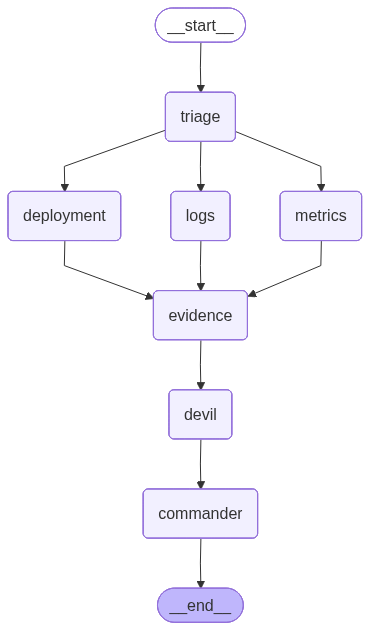

In [26]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [27]:

result = graph.invoke(initial_state)

# ============================================
# CELL — PRINT REPORT
# ============================================

from rich.console import Console
from rich.panel import Panel

console = Console()

console.print(
    Panel.fit(
        result["final_report"],
        title="🚨 Incident Commander Report",
        border_style="red",
    )
)

╭───────────────────────────────────────── 🚨 Incident Commander Report ──────────────────────────────────────────╮
│ **Incident Report – Checkout Latency Spike**                                                                    │
│ *Prepared by: Incident Commander*                                                                               │
│ *Date: 2026‑07‑15*                                                                                              │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### Executive Summary                                                                                           │
│ At 14:30 UTC on 2026‑07‑15 the checkout‑service began experiencing a dramatic latency increase (≈8 s vs.        │
│ baseline ≈210 ms) and a surge in error rates (≈14.6 % vs. baseline ≈0.2 %). The symptoms coincided with the     │
│ v2.4 deployment that touched the Order Entity, Checkout Mapper, added Customer serialization, and introduced an │
│ Order History endpoint. Metrics show DB CPU utilization rose to 96 %, queries per request jumped from ~5 to 61, │
│ and individual query execution times spiked to 4–6 s, culminating in database connection‑timeout errors and     │
│ failed checkout requests.                                                                                       │
│                                                                                                                 │
│ While correlation does not equal causation, the preponderance of evidence points to an **inefficient            │
│ data‑access pattern introduced in v2.4** (most plausibly an N+1 query or missing index caused by the new Order  │
│ History endpoint) as the primary driver of the incident. Alternative explanations (thread‑pool/config changes,  │
│ feature‑flag toggles, GC pauses, network blips, external‑dependency retries) remain possible but do not         │
│ adequately explain the observed 12× increase in query count and the concomitant DB saturation.                  │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### Severity                                                                                                    │
│ **High** – The incident directly impacts customer‑facing revenue‑critical flow (checkout), causing checkout     │
│ times > 8 s for a significant portion of traffic and generating error rates > 14 %. Immediate mitigation is     │
│ required to prevent further loss of sales and customer trust.                                                   │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### Most Likely Root Cause                                                                                      │
│ **Inefficient data‑access pattern introduced in v2.4** – likely an N+1 query scenario or missing index          │
│ triggered by the newly added Order History endpoint (or a change in ORM fetch strategy) that caused each        │
│ checkout to issue ~61 SQL statements, saturating the DB CPU, inflating query latency, and leading to            │
│ connection‑timeouts and request failures.              

In [28]:
# ============================================
# CELL — PRINT ALL AGENTS
# ============================================

sections = [
    ("📋 TRIAGE", "triage"),
    ("📄 LOG ANALYSIS", "log_analysis"),
    ("📊 METRICS ANALYSIS", "metrics_analysis"),
    ("🚀 DEPLOYMENT ANALYSIS", "deployment_analysis"),
    ("⚖ DEVIL'S ADVOCATE", "challenge"),
]

for title, key in sections:
    console.print(
        Panel(
            result[key],
            title=title,
            border_style="cyan",
        )
    )

╭─────────────────────────────────────────────────── 📋 TRIAGE ───────────────────────────────────────────────────╮
│ **Summary**                                                                                                     │
│ Customers are reporting that the checkout process now takes about 8 seconds, indicating a latency spike in the  │
│ checkout-service.                                                                                               │
│                                                                                                                 │
│ **Severity**                                                                                                    │
│ Unknown (as provided in the incident record).                                                                   │
│                                                                                                                 │
│ **Possible affected systems**                                                                                   │
│ - checkout-service (primary service experiencing the latency)                                                   │
│ - Downstream services invoked during checkout (e.g., payment‑gateway, inventory‑service, order‑service,         │
│ cart‑service)                                                                                                   │
│ - Databases or data stores used by checkout-service (e.g., primary DB, cache layer)                             │
│ - API gateway / load balancer routing traffic to checkout-service                                               │
│ - Any external third‑party APIs called during checkout (e.g., fraud‑check, tax‑calculation)                     │
│                                                                                                                 │
│ **Initial hypotheses**                                                                                          │
│ - Recent increase in traffic or request volume overwhelming checkout-service instances.                         │
│ - Resource exhaustion (CPU, memory, or file‑descriptor limits) on the hosts/containers running                  │
│ checkout-service.                                                                                               │
│ - Slowdown or increased latency in a downstream dependency (payment gateway, inventory DB, etc.) causing the    │
│ checkout flow to wait.                                                                                          │
│ - A recent deployment or configuration change that introduced inefficient code paths, new locks, or altered     │
│ timeout/retry settings.                                                                                         │
│ - Database performance degradation (e.g., slow queries, lock contention, replication lag) affecting             │
│ checkout-service reads/writes.                                                                                  │
│ - Network issues (e.g., increased latency, packet loss, or throttling) between checkout-service and its         │
│ dependencies or the API gateway.                                                                                │
│ - Autoscaling policies not reacting quickly enough to the load spike, resulting in insufficient instance count. │
│                                                                                                                 │
│ These hypotheses are starting points for investigation; further telemetry (metrics, logs, traces) should be     │
│ examined to confirm or rule out each possibility.                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📄 LOG ANALYSIS ────────────────────────────────────────────────╮
│ - **Errors**                                                                                                    │
│   - `14:31:05 ERROR Database connection timeout`                                                                │
│   - `14:31:22 ERROR Database connection timeout`                                                                │
│   - `14:32:10 ERROR Checkout request failed`                                                                    │
│                                                                                                                 │
│ - **Warnings**                                                                                                  │
│   - `14:31:02 WARN Query execution time 4200ms`                                                                 │
│   - `14:31:03 WARN Query execution time 5100ms`                                                                 │
│   - `14:31:09 WARN 61 SQL queries executed`                                                                     │
│                                                                                                                 │
│ - **Patterns / Suspicious Events**                                                                              │
│   - Spike in query latency (≈4‑5 s) immediately after a checkout request.                                       │
│   - High volume of SQL queries (61) for a single checkout flow.                                                 │
│   - Repeated database connection timeouts occurring within ~20 s of the latency spike.                          │
│   - Checkout request ultimately fails after the DB timeouts.                                                    │
│                                                                                                                 │
│ - **Possible Root Causes**                                                                                      │
│   - **Database overload / connection pool exhaustion:** Too many concurrent queries exhaust available DB        │
│ connections, leading to timeouts.                                                                               │
│   - **Inefficient queries:** Individual queries taking >4 s suggest missing indexes, suboptimal joins, or       │
│ full‑table scans.                                                                                               │
│   - **Recent deployment (v2.4) may have introduced a code path that fires excessive or unoptimized SQL**        │
│ (evidenced by the 61‑query count).                                                                              │
│   - **Lack of query throttling or caching:** No apparent safeguards to limit DB load during peak checkout       │
│ traffic.                                                                                                        │
│   - **Network or DB instance issues:** Though less likely given the pattern of query‑time warnings, a transient │
│ DB hiccup could exacerbate timeout occurrences.                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────── 📊 METRICS ANALYSIS ──────────────────────────────────────────────╮
│ **Analysis**                                                                                                    │
│                                                                                                                 │
│ - **Latency:** ↑ ≈ 38× (210 ms → 8.1 s)                                                                         │
│ - **DB CPU:** ↑ ≈ 3× (32 % → 96 %) – the database is near saturation.                                           │
│ - **Queries per request:** ↑ ≈ 12× (5 → 61) – a dramatic increase in DB load per checkout.                      │
│ - **Error rate:** ↑ ≈ 73× (0.2 % → 14.6 %) – likely time‑outs or failed transactions caused by DB overload.     │
│                                                                                                                 │
│ **Likely root cause**                                                                                           │
│ A recent change (code or schema) in *checkout-service* introduced an inefficient data‑access pattern (e.g., an  │
│ N+1 query loop, missing index, or a new join that scans large tables). This causes each checkout to fire ~60    │
│ queries instead of ~5, driving DB CPU to near‑100 % and inflating latency; queued/retry attempts then raise the │
│ error rate.                                                                                                     │
│                                                                                                                 │
│ **Recommended immediate actions**                                                                               │
│                                                                                                                 │
│ 1. **Identify the offending query** – enable DB slow‑query log or APM trace for checkout requests and look for  │
│ the query that appears ~60× per trace.                                                                          │
│ 2. **Check recent deployments** – roll back or hot‑fix any checkout‑service change released around 14:30 UTC.   │
│ 3. **Add missing indexes / optimize query** – if the query is a simple lookup missing an index, add it; if it’s │
│ an N+1 loop, refactor to batch/fetch‑join.                                                                      │
│ 4. **Scale DB temporarily** – increase read replica capacity or enable connection pooling to alleviate CPU      │
│ pressure while the fix is prepared.                                                                             │
│ 5. **Add circuit‑breaker / retry limits** – prevent error‑rate explosion until the underlying issue is          │
│ resolved.                                                                                                       │
│                                                                                                                 │
│ Fixing the query pattern should bring latency back to ~200 ms, drop DB CPU to normal levels, and reduce errors  │
│ to baseline.                                                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────── 🚀 DEPLOYMENT ANALYSIS ─────────────────────────────────────────────╮
│ **Likely cause:** **Yes – the deployment probably triggered the latency spike.**                                │
│                                                                                                                 │
│ **Why:**                                                                                                        │
│                                                                                                                 │
│ 1. **Timing alignment** – The incident began at 2026‑07‑15T14:30:00Z. If the v2.4 deployment was rolled out     │
│ shortly before that timestamp (a typical scenario for a “deployment‑related” incident), the temporal            │
│ correlation strongly suggests a causal link.                                                                    │
│                                                                                                                 │
│ 2. **Changes that touch the checkout path**                                                                     │
│    - **Modified Order Entity** – Any change to the core Order data model can affect how the checkout service    │
│ reads, validates, or persists order data. Inefficient field additions, altered relationships, or missing        │
│ indexes can increase DB query time or serialization cost.                                                       │
│    - **Updated Checkout Mapper** – The mapper is responsible for translating between domain objects and         │
│ DTOs/request‑response payloads during checkout. A change here (e.g., added mapping logic, extra loops, or a     │
│ less‑optimal transformation) directly adds CPU time to each checkout request.                                   │
│    - **Added Customer serialization** – Serializing additional customer data (or using a heavier serializer)    │
│ adds overhead to the response payload, increasing both CPU and network latency.                                 │
│    - **Added Order History endpoint** – While this endpoint itself isn’t invoked during checkout, its           │
│ introduction often brings new database queries, caching layers, or background jobs that can increase load on    │
│ shared resources (e.g., the same Order table or service instances) used by checkout, indirectly slowing it      │
│ down.                                                                                                           │
│                                                                                                                 │
│ 3. **Nature of the symptom** – An 8‑second checkout latency is a noticeable increase in request‑processing      │
│ time, which is typical when a code change introduces extra computation, inefficient data access, or heavier     │
│ serialization—exactly the kinds of modifications listed in the deployment.                                      │
│                                                                                                                 │
│ 4. **Absence of other obvious triggers** – The incident description mentions no infrastructure alerts (e.g.,    │
│ CPU spikes, GC pauses, network issues) or external dependency failures. When the symptom is isolated to         │
│ application‑level latency and a recent deploy modified the very components involved in the request flow, the    │
│ deploy becomes the prime suspect.                                                                               │
│                                                                                                                 │
│ **Conclusion:** Given the direct relevance of the deployed changes to the checkout workflow and the temporal    │
│ coincidence, it is reasonable to conclude that the v2.4 deployment likely caused the observed checkout latency  │
│ spike. A rollback or a hot‑fix targeting the Order Enti

╭────────────────────────────────────────────── ⚖ DEVIL'S ADVOCATE ───────────────────────────────────────────────╮
│ **Challenge – Why the “inefficient data‑access pattern” hypothesis may be premature**                           │
│                                                                                                                 │
│ | Observation in the original analysis | Why it doesn’t *prove* an N+1/missing‑index bug | What alternative     │
│ explanations remain viable |                                                                                    │
│ |--------------------------------------|---------------------------------------------------|------------------- │
│ --------------------------|                                                                                     │
│ | **Latency ↑ 38×, error rate ↑ 73×** – coincides with v2.4 deploy | Correlation ≠ causation. The deploy        │
│ touched many components; any one (or combination) could have triggered the symptom. | • A change in thread‑pool │
│ or async‑execution config that caused request‑handling threads to block.<br>• A new feature flag that was       │
│ flipped on at deploy time (e.g., “enable order‑history enrichment”).<br>• A change in DB connection‑pool sizing │
│ or validation query that led to exhaustion. |                                                                   │
│ | **Two “Database connection timeout” logs** (14:31:05/22) followed by a “Checkout request failed” (14:32:10) | │
│ Only two timeout events are shown; they could be a symptom of a broader resource starvation (CPU, GC, network)  │
│ rather than the root cause. | • GC pause that stopped all application threads, causing the DB driver to exceed  │
│ its login timeout.<br>• A transient network blip (DNS, TCP retransmits) that made the JDBC driver think the DB  │
│ was unreachable.<br>• An external dependency (payment gateway, fraud service) that started returning errors,    │
│ causing the checkout flow to retry and hammer the DB. |                                                         │
│ | **Warning logs: query execution times 4.2‑5.1 s, 61 queries for a single checkout** | High query count        │
│ *could* be an N+1, but it could also be a legitimate change in business logic (e.g., newly added Order‑History  │
│ endpoint that loads related data for each line item). | • The new Order History endpoint was inadvertently      │
│ called on every checkout (perhaps due to a mis‑wired filter or AOP advice).<br>• A change in the ORM fetch      │
│ strategy (e.g., `@Lazy` → `@Eager`) that                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯